Primarily following https://virtualcellmodels.cziscience.com/tutorial/scvi-tutorial

In [1]:
import os
from typing import Optional

import anndata
import faiss
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc
import scvi
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from tqdm.notebook import tqdm

In [2]:
CELLXGENE_MODEL_DIR_PATH = "../scvi-human-2025-11-08"
CENSUS_VERSION = "2025-11-08"
DISTANCE_METRIC = "euclidean"

FIGURES_DIR = "../../figures/cellxgene-2025-11-08"
SAVE_FIGURES = True
os.makedirs(FIGURES_DIR, exist_ok=True)

# Get embeddings

In [3]:
CM_ADATA_PATH = "/data/yosef2/users/ruchir/pan_vaccine_immune_response/compile_sc_data/ALL/scRNA_reprocessed/only_CM/cm_rna.platelet-mono-excluded.h5ad"
CM_ADATA_LABELED_PATH = "../../cluster/mrvi.leiden.labeled.h5ad"

In [4]:
def subset_to_vaccines(adata, vaccines):
    adata = adata[adata.obs["vaccine"].isin(vaccines)].copy()
    return adata


def copy_subcluster_metadata(adata):
    labeled_adata = sc.read_h5ad(CM_ADATA_LABELED_PATH)
    assert set(adata.obs_names).issubset(set(labeled_adata.obs_names))
    adata.obs["subcluster"] = labeled_adata.obs.loc[adata.obs_names, "subcluster"]
    adata.obs["subcluster_idx"] = labeled_adata.obs.loc[adata.obs_names, "subcluster_idx"]
    adata.obs["subcluster_label"] = labeled_adata.obs.loc[adata.obs_names, "subcluster_label"]
    return adata

In [5]:
query_adata = sc.read_h5ad(CM_ADATA_PATH)
assert len(set(query_adata.obs_names)) == query_adata.shape[0]
query_adata.var = query_adata.var.set_index("gene_ids")

# Add subcluster labels
query_adata = copy_subcluster_metadata(query_adata)

# Subset to non-multiome vaccines
query_adata = subset_to_vaccines(query_adata, ["H5N1+AS03", "H5N1", "TIV", "PFZR"])

In [6]:
ref_ensembl_ids = set(
    scvi.model.SCVI.prepare_query_anndata(
        query_adata, CELLXGENE_MODEL_DIR_PATH, return_reference_var_names=True
    )
)

n_match = len(set(query_adata.var.index) & ref_ensembl_ids)
print(f"{n_match}/{len(ref_ensembl_ids)} ids match")
assert len(set(query_adata.var.index)) == query_adata.shape[1]

INFO     File ../scvi-human-2025-11-08/model.pt already downloaded                                                 
5457/8000 ids match


In [7]:
TRAIN_ADAPTERS = False

query_adata.obs["batch"] = "unassigned"
scvi.model.SCVI.prepare_query_anndata(query_adata, CELLXGENE_MODEL_DIR_PATH, inplace=True)
vae_q = scvi.model.SCVI.load_query_data(query_adata, CELLXGENE_MODEL_DIR_PATH)

if TRAIN_ADAPTERS:
    vae_q.train(max_epochs=200, plan_kwargs={"weight_decay": 0.0})
    ax = vae_q.history["train_loss_epoch"].plot()
else:
    vae_q.is_trained = True

query_adata.obsm["cellxgene_scvi"] = vae_q.get_latent_representation()

INFO     File ../scvi-human-2025-11-08/model.pt already downloaded                                                 
INFO     Found 68.21249999999999% reference vars in query data.                                                    


/data/yosef3/scratch/ruchir/tools/mambaforge/envs/scvi-latest/lib/python3.12/site-packages/scvi/model/base/_archesmixin.py:322: UserWarning: Query data contains less than 80% of reference var names. This may result in poor performance.
  return _pad_and_sort_query_anndata(adata, var_names, inplace)


INFO     File ../scvi-human-2025-11-08/model.pt already downloaded                                                 


/data/yosef3/scratch/ruchir/tools/mambaforge/envs/scvi-latest/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /data/yosef3/scratch/ruchir/tools/mambaforge/envs/sc ...


# Check if subclusters are well seperated

In [8]:
sc.pp.neighbors(query_adata, n_neighbors=20, use_rep="cellxgene_scvi", metric=DISTANCE_METRIC)
sc.tl.umap(query_adata)

In [45]:
def plot_shuffled_umap(adata, color, s: int = 5, title: Optional[str] = None, ax: plt.Axes = None):
    permutation = np.random.permutation(adata.n_obs)
    if ax:
        sc.pl.umap(
            adata[permutation], color=color, frameon=False, s=s, title=title, ax=ax, show=False
        )
        for collection in ax.collections:
            collection.set_rasterized(True)
    else:
        sc.pl.umap(adata[permutation], color=color, frameon=False, s=s, title=title)


def plot_shuffled_umap_in_equal_proportions(
    adata,
    color,
    s: int = 5,
    title: Optional[str] = None,
    ax: Optional[plt.Axes] = None,
):
    min_count = adata.obs[color].value_counts().min()
    shuffled_idxs = []
    for category in adata.obs[color].unique():
        category_idxs = adata.obs[adata.obs[color] == category].index
        shuffled_idxs.extend(np.random.choice(category_idxs, min_count, replace=False))
    shuffled_idxs = np.array(shuffled_idxs)
    plot_shuffled_umap(adata[shuffled_idxs], color, s=s, title=title, ax=ax)


def plot_distribution_for_categories(adata, color):
    categories = sorted(adata.obs[color].unique())
    n_categories = len(categories)
    fig, axs = plt.subplots(ncols=n_categories, figsize=(n_categories * 3, 3), sharey=True)
    for i, category in enumerate(categories):
        ax = axs[i] if n_categories > 1 else axs
        adata.obs[f"is_{category}"] = adata.obs[color] == category
        sc.pl.umap(
            adata[adata.obs[f"is_{category}"]],
            color=f"is_{category}",
            frameon=False,
            s=5,
            ax=ax,
            show=False,
        )
        ax.set_title(category)
    plt.tight_layout()
    plt.show()

Silhouette score: 0.0182


/data/yosef3/scratch/ruchir/tools/mambaforge/envs/scvi-latest/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


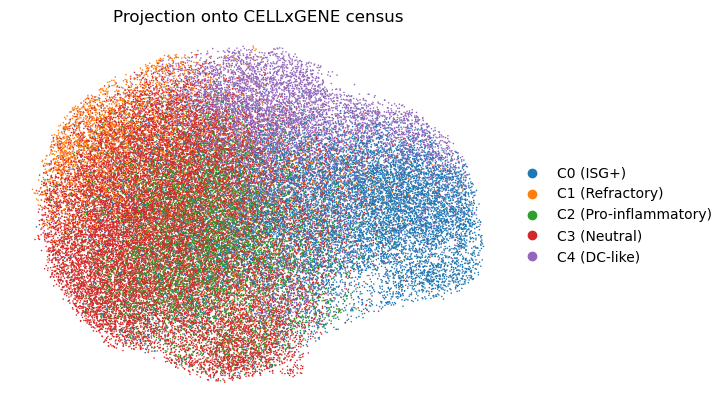

In [10]:
fig, ax = plt.subplots()
score = silhouette_score(
    query_adata.obsm["cellxgene_scvi"],
    query_adata.obs["subcluster"],
    metric=DISTANCE_METRIC,
    sample_size=20_000,
)
print(f"Silhouette score: {score:.4f}")
title = "Projection onto CELLxGENE census"
plot_shuffled_umap(query_adata, "subcluster", title=title, ax=ax, s=5)
if SAVE_FIGURES:
    plt.savefig(os.path.join(FIGURES_DIR, "cellxgene_projection.pdf"), dpi=500, bbox_inches="tight")
plt.show()

# Get reference anndata (top k nearest neighbors of query adata)

In [35]:
FAISS_INDEX_PATH = f"scvi_index_{DISTANCE_METRIC}.faiss"
REFERENCE_ADATA_PATH = "scvi_embeddings.h5ad"
N_REF_NEIGHBORS = 50

In [ ]:
# Load reference cells
print("Loading reference cells...")
ref_full = sc.read_h5ad(REFERENCE_ADATA_PATH)

### Use only KNN neighbors as reference

In [ ]:
# Load FAISS index
index = faiss.read_index(FAISS_INDEX_PATH)
index.nprobe = 20
print(f"Loaded FAISS index with {index.ntotal:,} vectors")

# Prepare query vectors for FAISS -- normalize only for correlation, never modify obsm in-place
query_vectors = query_adata.obsm["cellxgene_scvi"].astype(np.float32).copy()
if DISTANCE_METRIC == "correlation":
    query_vectors -= query_vectors.mean(axis=1, keepdims=True)
    norms = np.linalg.norm(query_vectors, axis=1, keepdims=True)
    query_vectors /= np.maximum(norms, 1e-10)

# For each query cell, find its N nearest reference cells
_, I = index.search(query_vectors, N_REF_NEIGHBORS)
del query_vectors

unique_ref_positions = sorted(set(I.ravel().tolist()))
print(
    f"Total unique reference cells: {len(unique_ref_positions):,} (max possible: {query_adata.shape[0] * N_REF_NEIGHBORS:,})"
)

Loaded FAISS index with 96,591,226 vectors
Total unique reference cells: 422,347 (max possible: 2,594,450)


In [40]:
ref_adata_knn = ref_full[unique_ref_positions].copy()
print(f"Loaded {ref_adata_knn.n_obs:,} reference cells")

Loaded 422,347 reference cells


In [ ]:
combined_adata_knn = anndata.concat(
    [query_adata, ref_adata_knn],
    join="outer",
    label="source",
    keys=["Query (our dataset)", "Reference (CELLxGENE)"],
)

/data/yosef3/scratch/ruchir/tools/mambaforge/envs/scvi-latest/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


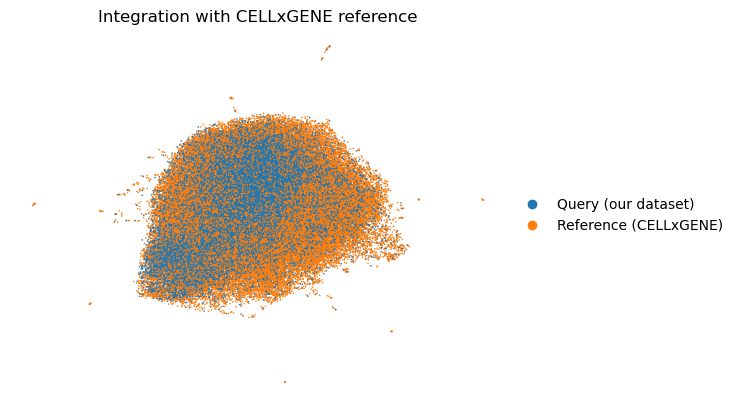

In [47]:
fig, ax = plt.subplots()
plot_shuffled_umap_in_equal_proportions(
    combined_adata_knn, "source", s=5, title="Integration with CELLxGENE reference", ax=ax
)
if SAVE_FIGURES:
    plt.savefig(
        os.path.join(FIGURES_DIR, "cellxgene_integration.pdf"), dpi=500, bbox_inches="tight"
    )
plt.show()

# For each cell in the reference, find closest n = 20 neighbors within query

In [69]:
N_QUERY_NEIGHBORS = 20

query_neigh_obj = NearestNeighbors(n_neighbors=N_QUERY_NEIGHBORS, metric=DISTANCE_METRIC)
query_neigh_obj = query_neigh_obj.fit(query_adata.obsm["scvi"])
query_neighbors = query_neigh_obj.kneighbors(ref_adata_knn.obsm["scvi"], return_distance=False)
ref_adata_knn.obsm["query_neighbors"] = query_neighbors

# Compute enrichment statistics per cell

In [70]:
def compute_subcluster_enrichment(ref_adata, query_adata, pseudocount: float = 0):
    subcluster_counts = query_adata.obs["subcluster_idx"].value_counts().to_dict()

    flat_query_neighbors = ref_adata.obsm["query_neighbors"].ravel()
    flat_query_neighbor_subclusters = query_adata.obs["subcluster_idx"].values[flat_query_neighbors]
    query_neighbor_subclusters = flat_query_neighbor_subclusters.reshape(
        ref_adata.obsm["query_neighbors"].shape
    )

    n_query_total = query_adata.shape[0]
    n_query_neighbors = query_neighbor_subclusters.shape[1]
    n_subclusters = len(subcluster_counts)

    for subcluster in subcluster_counts:
        n_neighbor_matches = (query_neighbor_subclusters == subcluster).sum(axis=1)
        numerator = (n_neighbor_matches + pseudocount) / (
            n_query_neighbors + pseudocount * n_subclusters
        )
        denominator = subcluster_counts[subcluster] / n_query_total
        enrichment = numerator / denominator
        ref_adata.obs[f"enrichment_{subcluster}"] = enrichment
    return ref_adata

In [71]:
def plot_subcluster_enrichment_by_feature(
    ref_adata, query_adata, feature_colname, n_clusters: int = 5, min_cells_per_feature: int = 1000
):
    # Subset to features with sufficient counts
    feature_counts = ref_adata.obs[feature_colname].value_counts().to_dict()
    valid_features = sorted([k for k, v in feature_counts.items() if v >= min_cells_per_feature])
    ref_adata_subset = ref_adata[ref_adata.obs[feature_colname].isin(valid_features)].copy()

    enrichment_colnames = [f"enrichment_C{i}" for i in range(n_clusters)]
    df = ref_adata_subset.obs[[feature_colname] + enrichment_colnames]
    df = df.melt(
        id_vars=feature_colname,
        value_vars=enrichment_colnames,
        var_name="subcluster",
        value_name="enrichment",
    )

    # Rename subcluster
    df["subcluster"] = df["subcluster"].str.replace("enrichment_", "")
    subcluster_idx_to_subcluster = dict(
        zip(query_adata.obs["subcluster_idx"], query_adata.obs["subcluster"])
    )
    df["subcluster"] = df["subcluster"].map(subcluster_idx_to_subcluster)

    # Add n examples to feature_colname
    df[feature_colname] = df[feature_colname].apply(lambda x: rf"{x} ($n={feature_counts[x]})$")

    # Get ordered feature_colname
    ys = df[feature_colname].unique()

    def extract_feature_name_without_n(y):
        return y.split(" ($n=")[0]

    ys = sorted(ys, key=lambda y: feature_counts[extract_feature_name_without_n(y)], reverse=True)

    ax = sns.barplot(data=df, x="enrichment", y=feature_colname, order=ys, hue="subcluster")
    ax.axvline(1, color="black", linestyle="--")
    ax.set(xlabel="enrichment", ylabel="", title=f"Enrichment of {feature_colname} by subcluster")

    # Place legend outside
    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0,
        title="Subcluster",
        title_fontsize="12",
        fontsize="10",
        frameon=False,
    )
    plt.show()

In [72]:
ref_adata_knn = compute_subcluster_enrichment(ref_adata_knn, query_adata, pseudocount=0)

In [73]:
ref_adata_knn.write(f"enrichment-ref_k={N_REF_NEIGHBORS}-query_k={N_QUERY_NEIGHBORS}.h5ad")
print(f"Saved to enrichment-ref_k={N_REF_NEIGHBORS}-query_k={N_QUERY_NEIGHBORS}.h5ad")

Saved to enrichment-ref_k=50-query_k=20.h5ad


By disease.

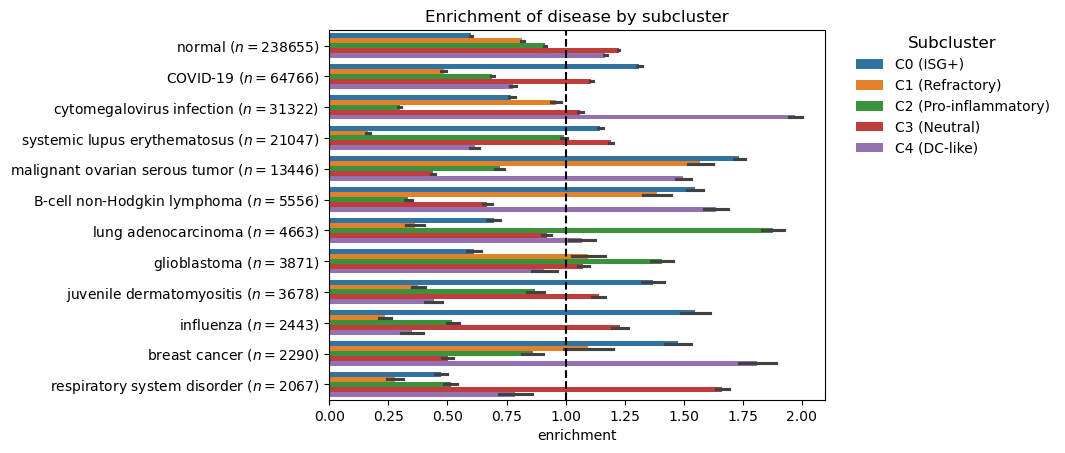

In [64]:
plot_subcluster_enrichment_by_feature(
    ref_adata_knn, query_adata, "disease", n_clusters=5, min_cells_per_feature=2_000
)

By cell type.

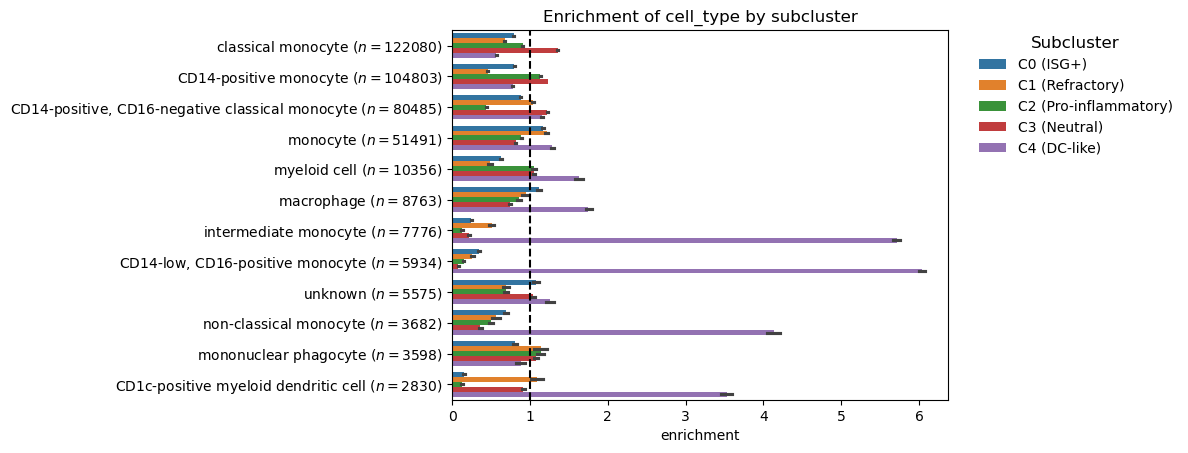

In [65]:
plot_subcluster_enrichment_by_feature(
    ref_adata_knn, query_adata, "cell_type", n_clusters=5, min_cells_per_feature=2_000
)

By tissue.

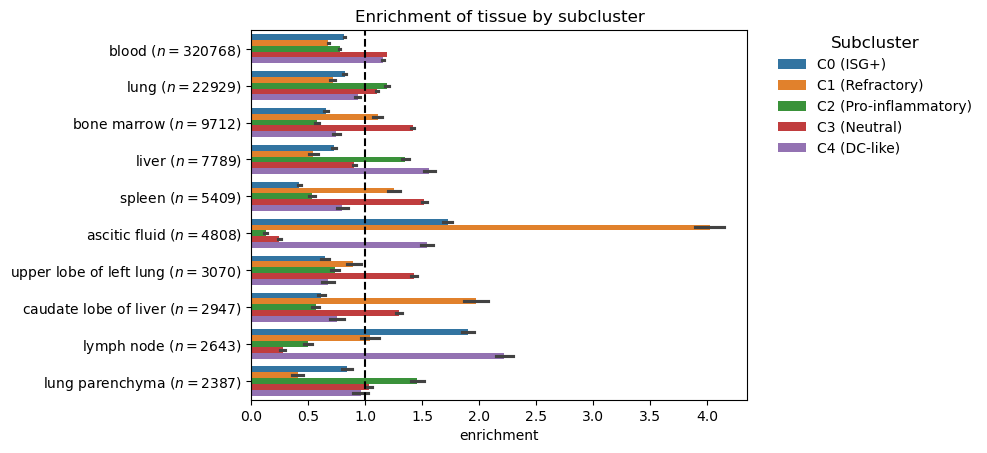

In [66]:
plot_subcluster_enrichment_by_feature(
    ref_adata_knn, query_adata, "tissue", n_clusters=5, min_cells_per_feature=2000
)

By assay.

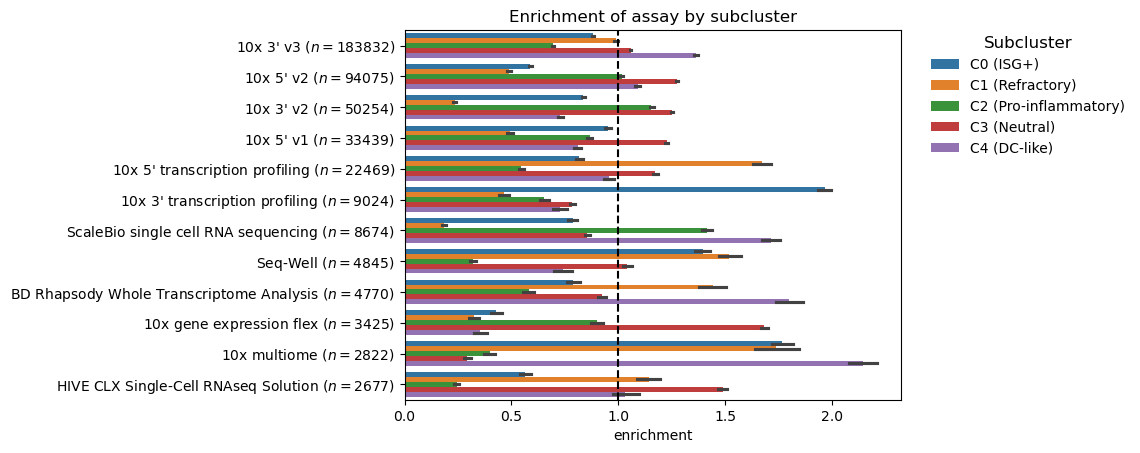

In [68]:
plot_subcluster_enrichment_by_feature(
    ref_adata_knn, query_adata, "assay", n_clusters=5, min_cells_per_feature=2000
)